In [ ]:
# let's try generating a threshold plot to compare thresholds of these different methods to see what should be improved / combined


# do exactly pymatching code
# check the exact logical errors from my DEM 
from clifford_deformed_cc_circuit import CDCompassCodeCircuit
from compass_code_correlated_error import CorrelatedDecoder
from pymatching import Matching
from stim import *
import numpy as np
import os
import pandas as pd

def get_circuit(d, p, l=2, eta=0.5, basis='X', CD_type="SC"):
    return CDCompassCodeCircuit(d=d, l=l, eta=eta, mem_type=basis).make_elongated_circuit_from_parity(before_measure_flip=p, 
                                                                                                    before_measure_pauli_channel=0,
                                                                                                    after_clifford_depolarization=p, 
                                                                                                    before_round_data_pauli_channel=0, 
                                                                                                    between_round_idling_pauli_channel=p, 
                                                                                                    idling_dephasing=0, 
                                                                                                    CD_type=CD_type)



def get_logical_error_rate(circuit, num_shots, decoder, basis='X', CD_type="SC"):
    sampler= circuit.compile_detector_sampler()
    dem = circuit.detector_error_model(decompose_errors=True, flatten_loops=True, approximate_disjoint_errors=True)
    dets, obs = sampler.sample(num_shots, separate_observables=True)
    matching_py_corr = Matching.from_detector_error_model(dem, enable_correlations=True)
    predictions_py_corr = matching_py_corr.decode_batch(dets, enable_correlations=True)
    num_logical_errors_py_corr = np.sum(np.any(np.array(obs) != np.array(predictions_py_corr), axis=1))
    num_logical_errors_my_corr = np.sum(decoder.decoding_failures_correlated_circuit_level(circuit, num_shots,basis, CD_type)) # not same seed, predictions or sampler so might be different
    
    return num_logical_errors_py_corr / num_shots, num_logical_errors_my_corr / num_shots

output_file = "ler_below_threshold.csv"
file_exists = os.path.isfile(output_file)
d = 9
ps = np.logspace(-2.5,-2.1, 3)
num_shots = 100_000
etas=[5]
l=4
CD_type = "SC"
basis = "X"

ler_all_eta = []
ler_all_eta_corr = []
rows = []

for eta in etas:
    ler_for_ps = []
    ler_for_ps_corr = []
    for p in ps:
        circuit = get_circuit(d=d, p=p, l=l,eta=eta, basis=basis, CD_type=CD_type)
        decoder = CorrelatedDecoder(eta=eta, d=d, l=l, corr_type="CORR_XZ", mem_type=basis)
        ler_pycorr, ler_my_corr = get_logical_error_rate(
            circuit=circuit, num_shots=num_shots, decoder=decoder, basis=basis, CD_type=CD_type
        )
        ler_for_ps.append(ler_pycorr)
        ler_for_ps_corr.append(ler_my_corr)
        rows.append({
            "l": l,
            "d": d,
            "CD_type": CD_type,
            "mem_type": basis,
            "num_shots": num_shots,
            "eta": eta,
            "p": p,
            "ler_pycorr": ler_pycorr,
            "ler_my_corr": ler_my_corr
        })
    ler_all_eta.append(ler_for_ps)
    ler_all_eta_corr.append(ler_for_ps_corr)
    print(f"finished eta={eta}")

df = pd.DataFrame(rows)
df.to_csv(
    output_file,
    mode='a',    
    header=not file_exists,
    index=False
)

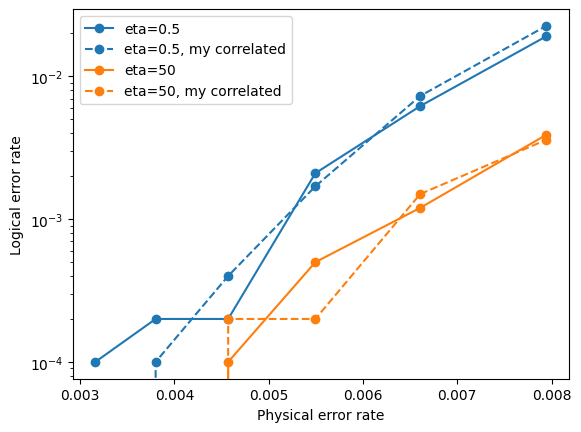

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure()
for i in range(len(etas)):
    eta = etas[i]
    lers = ler_all_eta[i]
    lers_corr = ler_all_eta_corr[i]

    line, = plt.plot(ps, lers,marker='o', label=f"eta={eta}")
    line_color = line.get_color()
    plt.plot(ps, lers_corr, "--", marker='o', label=f"eta={eta}, my correlated", color=line_color)


plt.yscale("log")
plt.xlabel("Physical error rate")
plt.ylabel("Logical error rate")
plt.legend(loc=0);
plt.show()